In [5]:
import pandas as pd

In [6]:
import os
os.listdir("C:/Users/User/Desktop/GitHub/lab-dw-pandas/lab-eda-univariate")

['.git',
 'amz_uk_price_prediction_dataset.csv.zip',
 'lab-eda-univariate.ipynb',
 'README.md']

In [7]:
df = pd.read_csv("C:/Users/User/Desktop/GitHub/lab-dw-pandas/lab-eda-univariate/amz_uk_price_prediction_dataset.csv.zip")

In [8]:
df.head()
df.columns

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='object')

In [9]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


In [10]:
df["category"].value_counts().head(10)

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Manicure & Pedicure Products               18940
Skin Care                                  18769
Make-up                                    18756
Hair Care                                  18735
Fragrances                                 18564
Name: count, dtype: int64

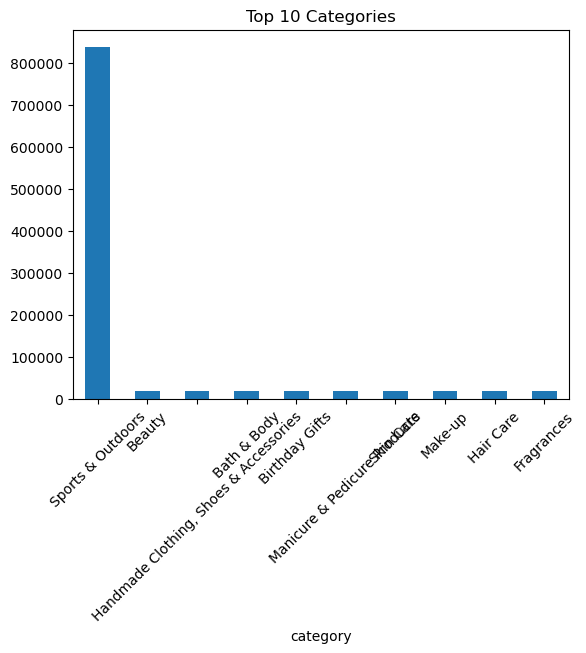

In [11]:
import matplotlib.pyplot as plt

df["category"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Categories")
plt.xticks(rotation=45)
plt.show()

In [12]:
ct = pd.crosstab(df["category"], df["isBestSeller"])
ct.head()

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3


In [13]:
ct["total"] = ct.sum(axis=1)
ct["best_seller_ratio"] = ct[True] / ct["total"]

ct_sorted = ct.sort_values("best_seller_ratio", ascending=False)
ct_sorted.head(10)

isBestSeller,False,True,total,best_seller_ratio
category,,,,
Grocery,9008,556,9564,0.058135
Smart Home Security & Lighting,98,6,104,0.057692
Health & Personal Care,9017,552,9569,0.057686
Mobile Phone Accessories,248,11,259,0.042471
Power & Hand Tools,8353,306,8659,0.035339
"Billiard, Snooker & Pool",241,8,249,0.032129
Pet Supplies,9152,285,9437,0.030200
Home Brewing & Wine Making,239,7,246,0.028455
Wind Instruments,243,7,250,0.028000


In [14]:
from scipy.stats import chi2_contingency
import numpy as np

chi2, p, dof, expected = chi2_contingency(pd.crosstab(df["category"], df["isBestSeller"]))

n = df.shape[0]
cramers_v = np.sqrt(chi2 / (n * (min(pd.crosstab(df["category"], df["isBestSeller"]).shape)-1)))

chi2, p, cramers_v

(np.float64(36540.20270061387),
 np.float64(0.0),
 np.float64(0.1222829439760564))

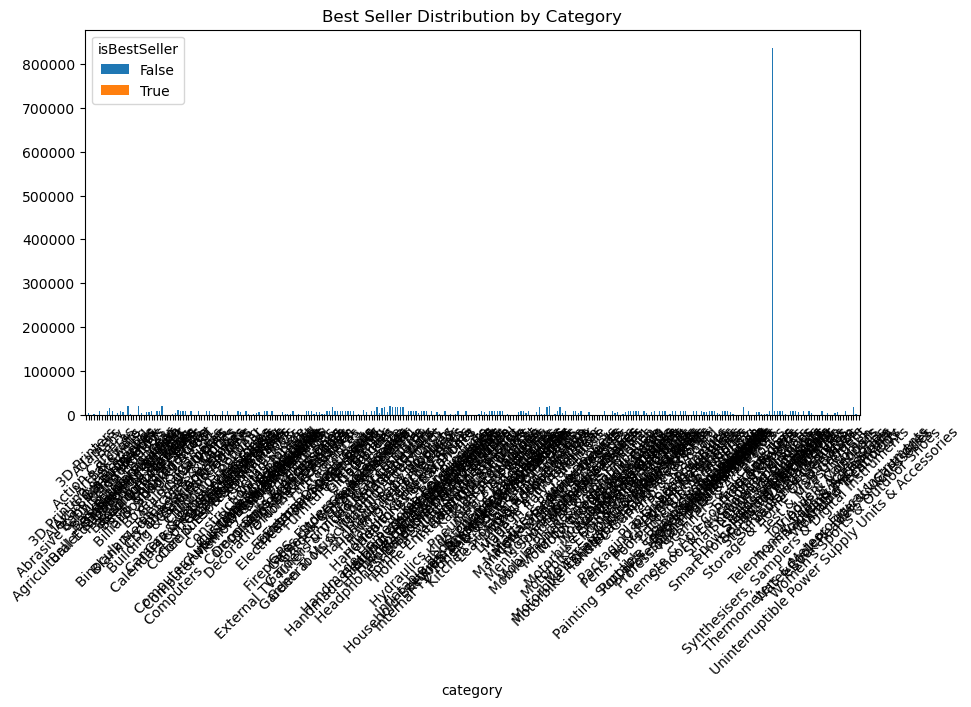

In [15]:
ct.iloc[:, :2].plot(kind="bar", stacked=True, figsize=(10,5))
plt.title("Best Seller Distribution by Category")
plt.xticks(rotation=45)
plt.show()

In [16]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[(df["price"] >= Q1 - 1.5*IQR) & (df["price"] <= Q3 + 1.5*IQR)]

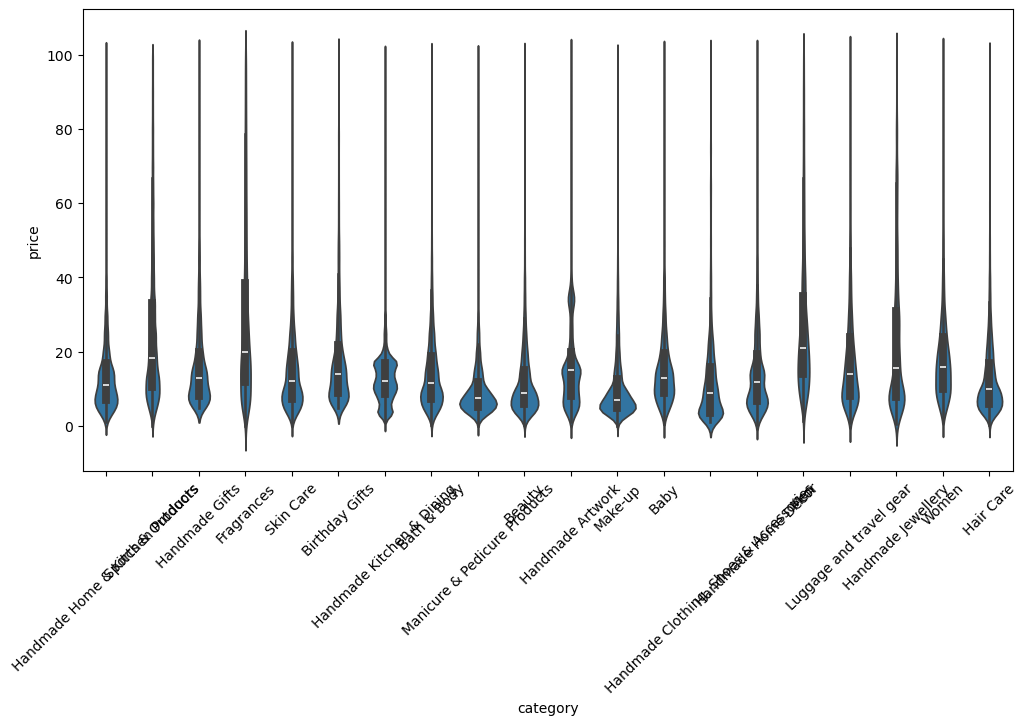

In [17]:
import seaborn as sns

top20 = df_clean["category"].value_counts().head(20).index

plt.figure(figsize=(12,6))
sns.violinplot(data=df_clean[df_clean["category"].isin(top20)], x="category", y="price")
plt.xticks(rotation=45)
plt.show()

In [18]:
df_clean.groupby("category")["price"].mean().sort_values(ascending=False).head(10)

category
Motherboards         68.772432
Boxing Shoes         67.417803
Desktop PCs          66.915562
Tablets              66.552971
Graphics Cards       65.103509
Digital Frames       60.745129
Streaming Clients    60.241803
Hockey Shoes         60.094796
Computer Cases       58.339884
Skiing Poles         57.867770
Name: price, dtype: float64

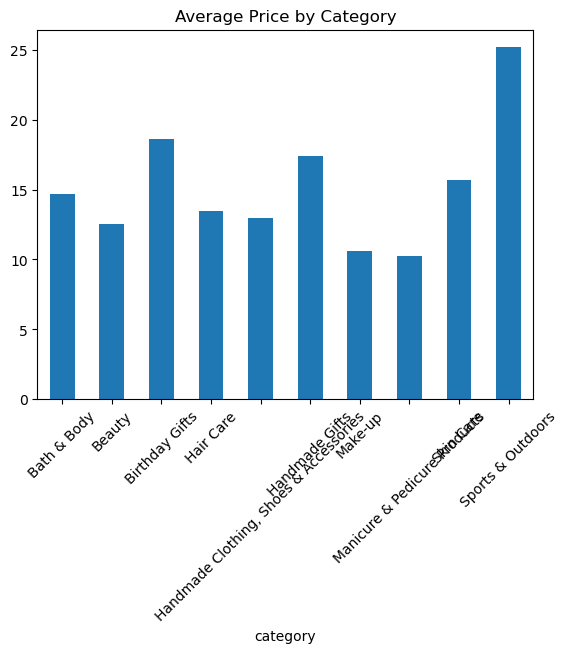

In [19]:
top10 = df_clean["category"].value_counts().head(10).index

avg_price = df_clean[df_clean["category"].isin(top10)].groupby("category")["price"].mean()

avg_price.plot(kind="bar")
plt.xticks(rotation=45)
plt.title("Average Price by Category")
plt.show()

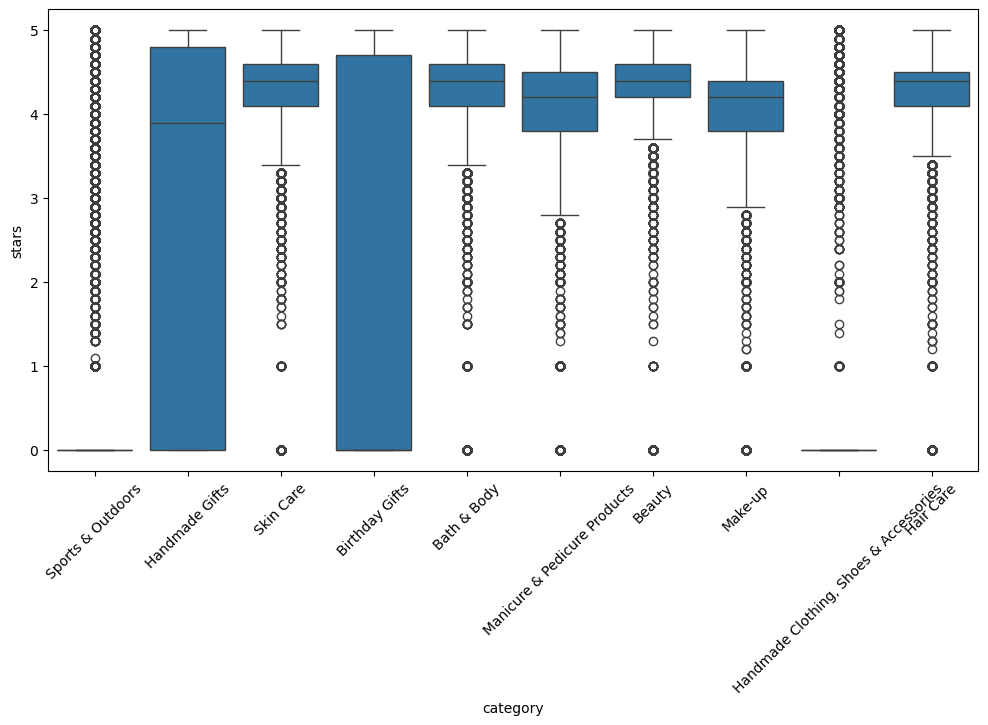

In [20]:
top10 = df_clean["category"].value_counts().head(10).index

plt.figure(figsize=(12,6))
sns.boxplot(data=df_clean[df_clean["category"].isin(top10)], x="category", y="stars")
plt.xticks(rotation=45)
plt.show()

In [21]:
df_clean[["price", "stars"]].corr()

,price,stars
price,1.000000,-0.077673
stars,-0.077673,1.000000


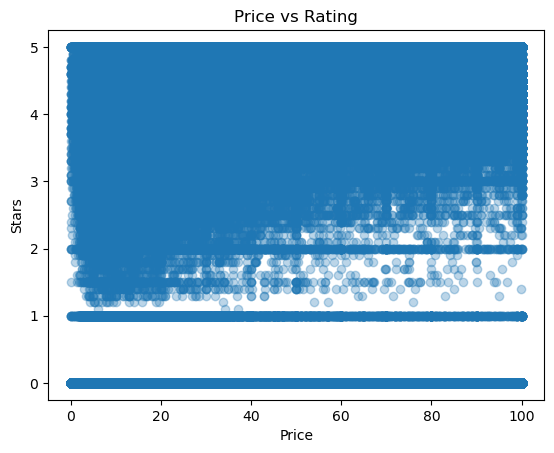

In [22]:
plt.scatter(df_clean["price"], df_clean["stars"], alpha=0.3)
plt.xlabel("Price")
plt.ylabel("Stars")
plt.title("Price vs Rating")
plt.show()

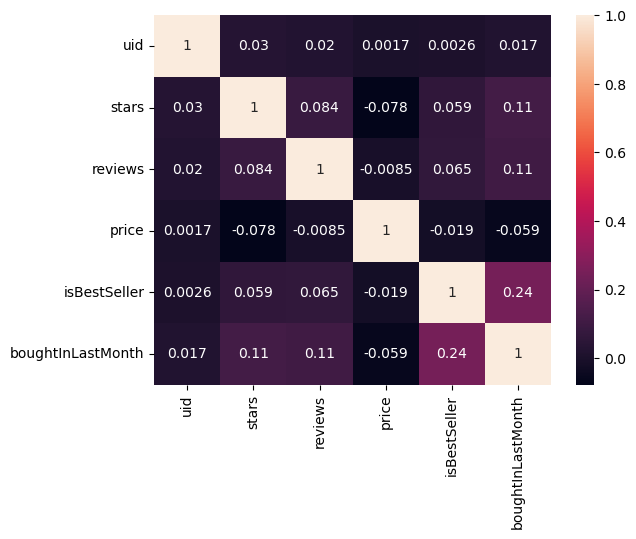

In [24]:
sns.heatmap(df_clean.corr(numeric_only=True), annot=True)
plt.show()

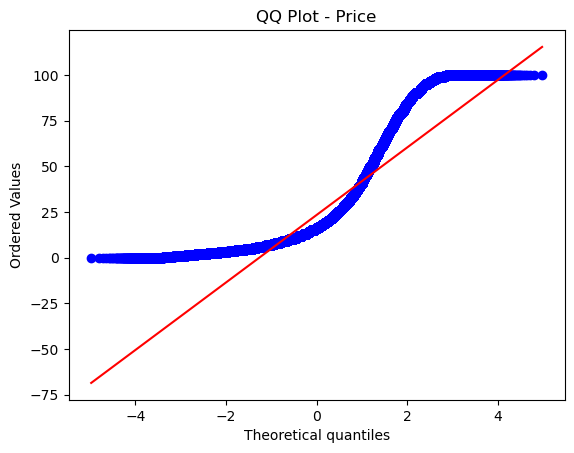

In [25]:
import scipy.stats as stats

stats.probplot(df_clean["price"], dist="norm", plot=plt)
plt.title("QQ Plot - Price")
plt.show()

In [26]:
df[["price","stars"]].corr()

,price,stars
price,1.000000,-0.124907
stars,-0.124907,1.000000
